In [116]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import matplotlib.pyplot as plt
import time
import numpy as np

LOG.propagate = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [150]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.connect()

2026-03-04 03:07:04,821 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:42:0c:78:b8:49
2026-03-04 03:07:04,822 | INFO     |: Scanning for device with address: c0:42:0c:78:b8:49, service UUID: d427e7cc-c400-4597-b417-d564e20d6600
2026-03-04 03:07:14,896 | INFO     |: Found 1 device(s) advertising service d427e7cc-c400-4597-b417-d564e20d6600
2026-03-04 03:07:14,898 | INFO     |: Selecting device: F32F03E1-EF13-6043-59E7-D2AE8E670FC2 (name: Artemis BLE)
2026-03-04 03:07:15,735 | INFO     |: Connected to c0:42:0c:78:b8:49


In [283]:
ble.reload_config()

In [151]:
times = []
dist = []

def tof_notification_handler(sender, data: bytearray):
    s = ble.bytearray_to_string(data).split("|")
    if len(s) == 2:
        t = float(s[0][2:])
        d = float(s[1][2:])

        times.append(t)
        dist.append(d)

        print (f"T={t:7.2f}   d={d:7.2f}")

In [152]:
ble.start_notify(ble.uuid["RX_STRING"], tof_notification_handler)


In [ ]:
times = []
dist = []

ble.send_command(CMD.START_COLLECT_DATA, "")
time.sleep(10)
ble.send_command(CMD.GET_TOF_READINGS, "")

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/y1hhnn/.pyenv/versions/3.13.2/lib/python3.13/asyncio/events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: cannot enter context: <_contextvars.Context object at 0x103d24a00> is already entered


T=1896671.00   d=3419.00
T=1896767.00   d=3438.00
T=1896859.00   d=3437.00
T=1896954.00   d=3453.00
T=1897052.00   d=3439.00
T=1897141.00   d=3497.00
T=1897236.00   d=3468.00
T=1897330.00   d=3412.00
T=1897424.00   d=3403.00
T=1897520.00   d=3428.00
T=1897615.00   d=3541.00
T=1897706.00   d=3417.00
T=1897801.00   d=3466.00
T=1897894.00   d=3412.00
T=1897990.00   d=3467.00
T=1898083.00   d=3466.00
T=1898179.00   d=3411.00
T=1898271.00   d=3436.00
T=1898365.00   d=3339.00
T=1898459.00   d=3450.00
T=1898553.00   d=3644.00
T=1898649.00   d=3440.00
T=1898741.00   d=3431.00
T=1898836.00   d=3471.00
T=1898929.00   d=3380.00
T=1899023.00   d=3346.00
T=1899118.00   d=3457.00
T=1899211.00   d=3462.00
T=1899307.00   d=3438.00
T=1899403.00   d=3513.00
T=1899496.00   d=3438.00
T=1899588.00   d=3382.00
T=1899683.00   d=3496.00
T=1899777.00   d=3622.00
T=1899870.00   d=3442.00
T=1899966.00   d=3431.00
T=1900058.00   d=3438.00
T=1900153.00   d=3534.00
T=1900246.00   d=3440.00
T=1900345.00   d=3441.00


In [260]:
dark_13 = dist
print(dark_13)

[3419.0, 3438.0, 3437.0, 3453.0, 3439.0, 3497.0, 3468.0, 3412.0, 3403.0, 3428.0, 3541.0, 3417.0, 3466.0, 3412.0, 3467.0, 3466.0, 3411.0, 3436.0, 3339.0, 3450.0, 3644.0, 3440.0, 3431.0, 3471.0, 3380.0, 3346.0, 3457.0, 3462.0, 3438.0, 3513.0, 3438.0, 3382.0, 3496.0, 3622.0, 3442.0, 3431.0, 3438.0, 3534.0, 3440.0, 3441.0, 3388.0, 3432.0, 3432.0, 3390.0, 3364.0, 3427.0, 3461.0, 3388.0, 3379.0, 3391.0, 3356.0, 3441.0, 3469.0, 3397.0, 3398.0, 3391.0, 3408.0, 3478.0, 3403.0, 3431.0, 3444.0, 3517.0, 3416.0, 3510.0, 3460.0, 3451.0, 3370.0, 3461.0, 3508.0, 3392.0, 3380.0, 3426.0, 3435.0, 3398.0, 3481.0, 3492.0, 3445.0, 3462.0, 3458.0, 3404.0, 3410.0, 3371.0, 3450.0, 3371.0, 3369.0, 3356.0, 3497.0, 3476.0, 3375.0, 3489.0, 3412.0, 3416.0, 3431.0, 3375.0, 3418.0, 3439.0, 3399.0, 3501.0, 3406.0, 3482.0, 3355.0, 3411.0, 3495.0, 3404.0, 3478.0, 3494.0, 3480.0]


In [261]:
print(dark_0025)
print(dark_005)
print(dark_01)
print(dark_02)
print(dark_03)
print(dark_04)
print(dark_05)
print(dark_06)
print(dark_07)
print(dark_08)
print(dark_09)
print(dark_10)
print(dark_11)
print(dark_12)
print(dark_13)

[89.0, 91.0, 90.0, 91.0, 92.0, 89.0, 91.0, 90.0, 90.0, 93.0, 90.0, 91.0, 90.0, 91.0, 92.0, 90.0, 91.0, 91.0, 92.0, 91.0, 90.0, 92.0, 91.0, 91.0, 91.0, 91.0, 91.0, 90.0, 92.0, 91.0, 91.0, 92.0, 91.0, 89.0, 92.0, 91.0, 90.0, 92.0, 93.0, 89.0, 92.0, 93.0, 90.0, 90.0, 92.0, 91.0, 91.0, 89.0, 91.0, 91.0, 90.0, 91.0, 90.0, 91.0, 92.0, 90.0, 89.0, 89.0, 92.0, 87.0, 91.0, 90.0, 92.0, 91.0, 91.0, 89.0, 91.0, 91.0, 89.0, 92.0, 91.0, 91.0, 90.0, 93.0, 91.0, 91.0, 89.0, 90.0, 90.0, 90.0, 90.0, 90.0, 91.0, 89.0, 89.0, 91.0, 90.0, 89.0, 91.0, 91.0, 89.0, 92.0, 91.0, 90.0, 91.0, 91.0, 89.0, 89.0, 90.0, 90.0, 91.0, 91.0, 89.0, 89.0, 89.0, 90.0, 91.0, 91.0, 90.0, 93.0, 89.0, 90.0, 89.0, 90.0, 91.0, 90.0, 91.0, 90.0, 90.0, 89.0, 89.0, 89.0, 88.0, 88.0, 90.0, 90.0, 89.0, 89.0, 89.0, 89.0, 89.0, 91.0, 89.0, 88.0, 90.0, 88.0, 89.0, 90.0, 89.0, 89.0, 89.0, 89.0, 89.0, 89.0, 89.0, 89.0, 88.0, 89.0, 88.0, 89.0, 88.0, 88.0, 88.0, 87.0, 89.0, 89.0, 89.0, 87.0, 90.0, 90.0, 90.0, 90.0, 90.0, 88.0, 90.0, 89.0, 91.

In [210]:
print(dis_0025)
print(dis_005)
print(dis_01)
print(dis_02)
print(dis_03)
print(dis_04)
print(dis_05)
print(dis_06)
print(dis_07)
print(dis_08)
print(dis_09)
print(dis_10)
print(dis_11)
print(dis_12)
print(dis_13)

[87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0]
[166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0,

In [12]:
ble.stop_notify(ble.uuid["RX_STRING"])

In [262]:
bright_0025 = np.array(dis_0025)
bright_005 = np.array(dis_005)
bright_01 = np.array(dis_01)
bright_02 = np.array(dis_02)
bright_03 = np.array(dis_03)
bright_04 = np.array(dis_04)
bright_05 = np.array(dis_05)
bright_06 = np.array(dis_06)
bright_07 = np.array(dis_07)
bright_08 = np.array(dis_08)
bright_09 = np.array(dis_09)
bright_10 = np.array(dis_10)
bright_11 = np.array(dis_11)
bright_12 = np.array(dis_12)
bright_13 = np.array(dis_13)
np.savez("bright.npz", bright_0025=bright_0025, bright_005=bright_005, bright_01=bright_01, bright_02=bright_02, bright_03=bright_03, bright_04=bright_04, bright_05=bright_05, bright_06=bright_06, bright_07=bright_07, bright_08=bright_08, bright_09=bright_09, bright_10=bright_10, bright_11=bright_11, bright_12=bright_12, bright_13=bright_13) 

In [263]:
dark_0025 = np.array(dark_0025)
dark_005 = np.array(dark_005)
dark_01 = np.array(dark_01)
dark_02 = np.array(dark_02)
dark_03 = np.array(dark_03)
dark_04 = np.array(dark_04)
dark_05 = np.array(dark_05)
dark_06 = np.array(dark_06)
dark_07 = np.array(dark_07)
dark_08 = np.array(dark_08)
dark_09 = np.array(dark_09)
dark_10 = np.array(dark_10)
dark_11 = np.array(dark_11)
dark_12 = np.array(dark_12)
dark_13 = np.array(dark_13)
np.savez("dark.npz", dark_0025=dark_0025, dark_005=dark_005, dark_01=dark_01, dark_02=dark_02, dark_03=dark_03, dark_04=dark_04, dark_05=dark_05, dark_06=dark_06, dark_07=dark_07, dark_08=dark_08, dark_09=dark_09, dark_10=dark_10, dark_11=dark_11, dark_12=dark_12, dark_13=dark_13)

In [ ]:
dark_0025 = dark_0025[:100]
dark_005 = dark_005[:100]
dark_01 = dark_01[:100]
dark_02 = dark_02[:100]
dark_03 = dark_03[:100]
dark_04 = dark_04[:100]
dark_05 = dark_05[:100]
dark_06 = dark_06[:100]
dark_07 = dark_07[:100]
dark_08 = dark_08[:100]
dark_09 = dark_09[:100]
dark_10 = dark_10[:100]
dark_11 = dark_11[:100]
dark_12 = dark_12[:100]
dark_13 = dark_13[:100]

100


In [265]:
bright_0025 =bright_0025[:100]
bright_005 = bright_005[:100]
bright_01 = bright_01[:100]
bright_02 = bright_02[:100]
bright_03 = bright_03[:100]
bright_04 = bright_04[:100]
bright_05 = bright_05[:100]
bright_06 = bright_06[:100]
bright_07 = bright_07[:100]
bright_08 = bright_08[:100]
bright_09 = bright_09[:100]
bright_10 = bright_10[:100]
bright_11 = bright_11[:100]
bright_12 = bright_12[:100]
bright_13 = bright_13[:100]

In [271]:
dark_data = {
    "0.25 ft": dark_0025, "0.5 ft": dark_005, "1 ft": dark_01, "2 ft": dark_02,
    "3 ft": dark_03, "4 ft": dark_04, "5 ft": dark_05, "6 ft": dark_06,
    "7 ft": dark_07, "8 ft": dark_08, "9 ft": dark_09, "10 ft": dark_10,
    "11 ft": dark_11, "12 ft": dark_12, "13 ft": dark_13
}

bright_data = {
    "0.25 ft": bright_0025, "0.5 ft": bright_005, "1 ft": bright_01, "2 ft": bright_02,
    "3 ft": bright_03, "4 ft": bright_04, "5 ft": bright_05, "6 ft": bright_06,
    "7 ft": bright_07, "8 ft": bright_08, "9 ft": bright_09, "10 ft": bright_10,
    "11 ft": bright_11, "12 ft": bright_12, "13 ft": bright_13
}

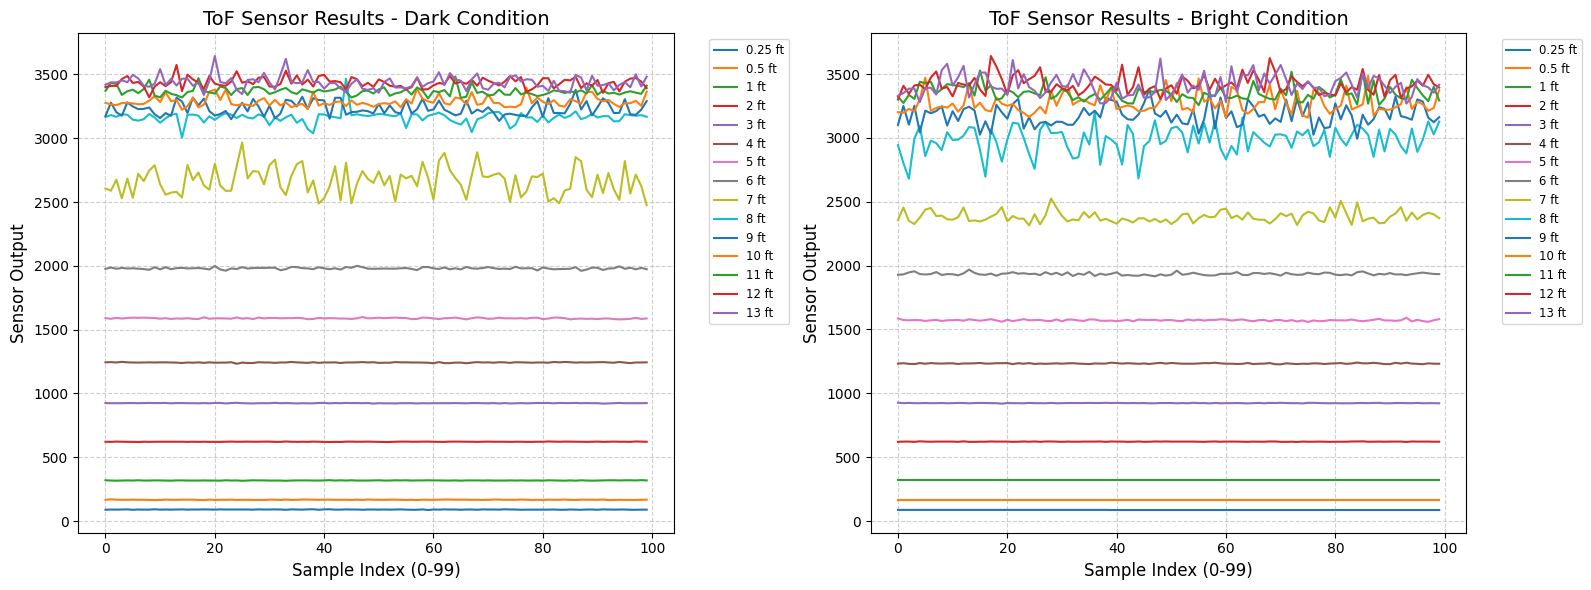

In [ ]:
# 2. 创建画布：1 行 2 列，设置合适的宽度和高度
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# X 轴表示 100 个采样点
x = range(100)

# 3. 绘制 Dark Condition (左图)
for label, data in dark_data.items():
    axes[0].plot(x, data, label=label)

axes[0].set_title('ToF Sensor Results - Dark Condition', fontsize=14)
axes[0].set_xlabel('Sample Index (0-99)', fontsize=12)
axes[0].set_ylabel('Sensor Output (mm)', fontsize=12) # 如果你的y轴是实际测量距离，可以改成 'Measured Distance'
axes[0].grid(True, linestyle='--', alpha=0.6)
# 因为有15条线，将图例放到图表外侧避免遮挡数据
axes[0].legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='small')

# 4. 绘制 Bright Condition (右图)
for label, data in bright_data.items():
    axes[1].plot(x, data, label=label)

axes[1].set_title('ToF Sensor Results - Bright Condition', fontsize=14)
axes[1].set_xlabel('Sample Index (0-99)', fontsize=12)
axes[1].set_ylabel('Sensor Output', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='small')

# 5. 调整布局并显示
plt.tight_layout()
plt.show()

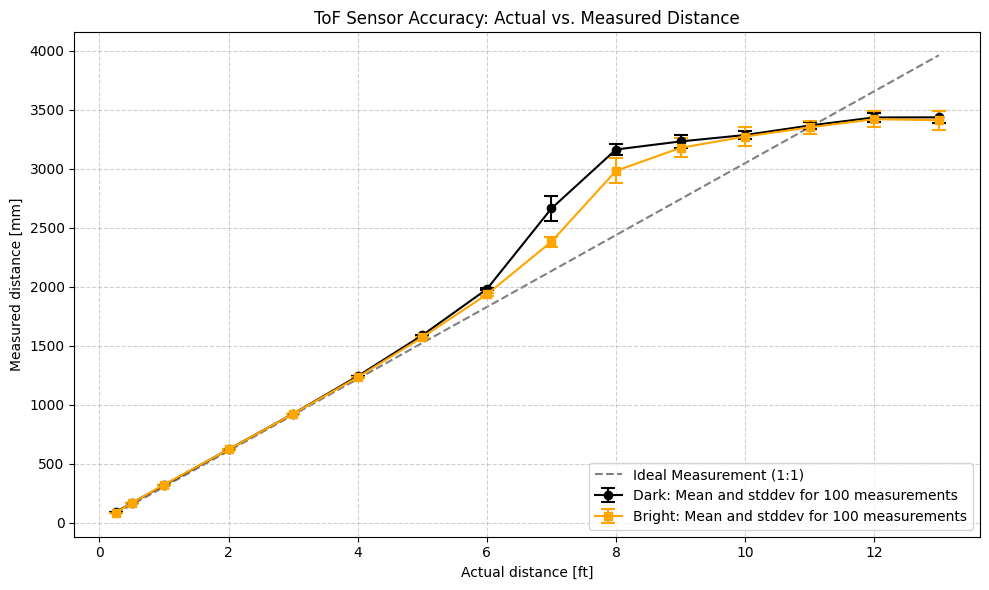

In [282]:
# 1. Define your X-axis: The actual distances you measured (in feet)
actual_distances = [0.25, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

# 2. Group your raw data arrays in the exact same order as the actual_distances list
# (Assuming your dark_0025, bright_0025, etc., are already loaded in your environment)
dark_raw_data = [
    dark_0025, dark_005, dark_01, dark_02, dark_03, 
    dark_04, dark_05, dark_06, dark_07, dark_08, 
    dark_09, dark_10, dark_11, dark_12, dark_13
]

bright_raw_data = [
    bright_0025, bright_005, bright_01, bright_02, bright_03, 
    bright_04, bright_05, bright_06, bright_07, bright_08, 
    bright_09, bright_10, bright_11, bright_12, bright_13
]

# 3. Calculate Mean and Standard Deviation
dark_means = [np.mean(data) for data in dark_raw_data]
dark_stds = [np.std(data) for data in dark_raw_data]

bright_means = [np.mean(data) for data in bright_raw_data]
bright_stds = [np.std(data) for data in bright_raw_data]

# 4. Create the plot
plt.figure(figsize=(10, 6))

# --- NEW: Add the Ideal Reference Line (y = x) ---
# We use actual_distances for both X and Y to create a perfect 1:1 slope.
# zorder=1 pushes this line behind your data points (which default to zorder=2).
plt.plot(actual_distances, [dis * 304.8 for dis in actual_distances], label='Ideal Measurement (1:1)', 
         linestyle='--', color='gray', zorder=1)
# -------------------------------------------------

# Plot Dark condition with error bars
plt.errorbar(actual_distances, dark_means, yerr=dark_stds, 
             label='Dark: Mean and stddev for 100 measurements', 
             fmt='-o', color='black', capsize=5, capthick=1.5, elinewidth=1.5, zorder=2)

# Plot Bright condition with error bars
plt.errorbar(actual_distances, bright_means, yerr=bright_stds, 
             label='Bright: Mean and stddev for 100 measurements', 
             fmt='-s', color='orange', capsize=5, capthick=1.5, elinewidth=1.5, zorder=2)

# 5. Format the graph
plt.title('ToF Sensor Accuracy: Actual vs. Measured Distance')
plt.xlabel('Actual distance [ft]')
plt.ylabel('Measured distance [mm]')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.tight_layout()
plt.show()

In [318]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.connect()

2026-03-04 05:04:47,693 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:42:0c:78:b8:49
2026-03-04 05:04:47,693 | INFO     |: Scanning for device with address: c0:42:0c:78:b8:49, service UUID: d427e7cc-c400-4597-b417-d564e20d6600
2026-03-04 05:04:57,744 | INFO     |: Found 1 device(s) advertising service d427e7cc-c400-4597-b417-d564e20d6600
2026-03-04 05:04:57,746 | INFO     |: Selecting device: F32F03E1-EF13-6043-59E7-D2AE8E670FC2 (name: Artemis BLE)
2026-03-04 05:04:58,655 | INFO     |: Connected to c0:42:0c:78:b8:49


In [319]:
times = []
dist1 = []
dist2 = []

def tof_notification_handler(sender, data: bytearray):
    s = ble.bytearray_to_string(data).split("|")
    if len(s) == 3:
        t = float(s[0][2:])
        d1 = float(s[1][3:])
        d2 = float(s[2][3:])

        times.append(t)
        dist1.append(d1)
        dist2.append(d2)
        print (f"T={t:7.2f}   d1={d1:7.2f}   d2={d2:7.2f}")

In [320]:
times = []
compR = []
compP = []


def comp_notification_handler(sender, data: bytearray):
    s = ble.bytearray_to_string(data).split("|")
    if len(s) == 3:
        t = float(s[0][2:])
        r = float(s[1][2:])
        p = float(s[2][2:])
        times.append(t)
        compR.append(r)
        compP.append(p)

        print (f"T={t:7.2f}   r={r:7.2f}   p={p:7.2f}")

In [321]:
times = []
dist1 = []
dist2 = []

ble.send_command(CMD.START_COLLECT_DATA, "")
time.sleep(20)

In [ ]:
ble.start_notify(ble.uuid["RX_STRING"], tof_notification_handler)
ble.send_command(CMD.GET_TOF_READINGS, "")

T=77078.00   d1= 569.00   d2= 574.00
T=77171.00   d1= 569.00   d2= 574.00
T=77360.00   d1= 567.00   d2= 575.00
T=77547.00   d1= 568.00   d2= 575.00
T=77736.00   d1= 566.00   d2= 577.00
T=77924.00   d1= 569.00   d2= 576.00
T=78112.00   d1= 567.00   d2= 575.00
T=78300.00   d1= 568.00   d2= 575.00
T=78489.00   d1= 568.00   d2= 573.00
T=78677.00   d1= 568.00   d2= 574.00
T=78865.00   d1= 568.00   d2= 574.00
T=79054.00   d1= 569.00   d2= 575.00
T=79242.00   d1= 567.00   d2= 573.00
T=79431.00   d1= 567.00   d2= 573.00
T=79618.00   d1= 569.00   d2= 575.00
T=79810.00   d1= 569.00   d2= 574.00
T=79996.00   d1= 568.00   d2= 575.00
T=80183.00   d1= 569.00   d2= 573.00
T=80372.00   d1= 565.00   d2= 575.00
T=80561.00   d1= 567.00   d2= 574.00
T=80749.00   d1= 568.00   d2= 574.00
T=80938.00   d1= 566.00   d2= 573.00
T=81126.00   d1= 567.00   d2= 574.00
T=81315.00   d1= 566.00   d2= 572.00
T=81503.00   d1= 567.00   d2= 574.00
T=81690.00   d1= 566.00   d2= 572.00
T=81879.00   d1= 567.00   d2= 571.00
T

In [323]:
ble.stop_notify(ble.uuid["RX_STRING"])
ble.start_notify(ble.uuid["RX_STRING"], comp_notification_handler)
ble.send_command(CMD.GET_COMP_READINGS, "")

T=77078.00   r=   0.00   p=   0.00
T=77171.00   r=   3.07   p=   2.78
T=77360.00   r=   8.34   p=   7.51
T=77547.00   r=  15.06   p=  13.54
T=77736.00   r=  22.68   p=  20.38
T=77924.00   r=  30.75   p=  27.63
T=78112.00   r=  38.95   p=  35.00
T=78300.00   r=  47.08   p=  42.31
T=78489.00   r=  54.97   p=  49.41
T=78677.00   r=  62.53   p=  56.20
T=78865.00   r=  69.67   p=  62.62
T=79054.00   r=  76.32   p=  68.63
T=79242.00   r=  82.49   p=  74.22
T=79431.00   r=  88.18   p=  79.38
T=79618.00   r=  93.38   p=  84.09
T=79810.00   r=  98.12   p=  88.39
T=79996.00   r= 102.40   p=  92.24
T=80183.00   r= 106.24   p=  95.73
T=80372.00   r= 109.70   p=  98.87
T=80561.00   r= 112.85   p= 101.72
T=80749.00   r= 115.69   p= 104.27
T=80938.00   r= 118.24   p= 106.54
T=81126.00   r= 120.51   p= 108.55
T=81315.00   r= 122.54   p= 110.36
T=81503.00   r= 124.35   p= 111.99
T=81690.00   r= 125.93   p= 113.42
T=81879.00   r= 127.35   p= 114.68
T=82072.00   r= 128.63   p= 115.84
T=82256.00   r= 129.

In [335]:
times = np.array(times) 
compR = np.array(compR) 
compP = np.array(compP) 
dist1 = np.array(dist1)
dist2 = np.array(dist2)

times = np.array(times) - times[0]
print(times)

[   0.   93.  282.  469.  658.  846. 1034. 1222. 1411. 1599. 1787. 1976.
 2164. 2353. 2540. 2732. 2918. 3105. 3294. 3483. 3671. 3860. 4048. 4237.
 4425. 4612. 4801. 4994. 5178. 5366. 5555. 5744. 5932. 6119. 6308. 6500.
 6684. 6874. 7061. 7254. 7438. 7626. 7818. 8003. 8192. 8380. 8570. 8757.
 8944. 9137.]


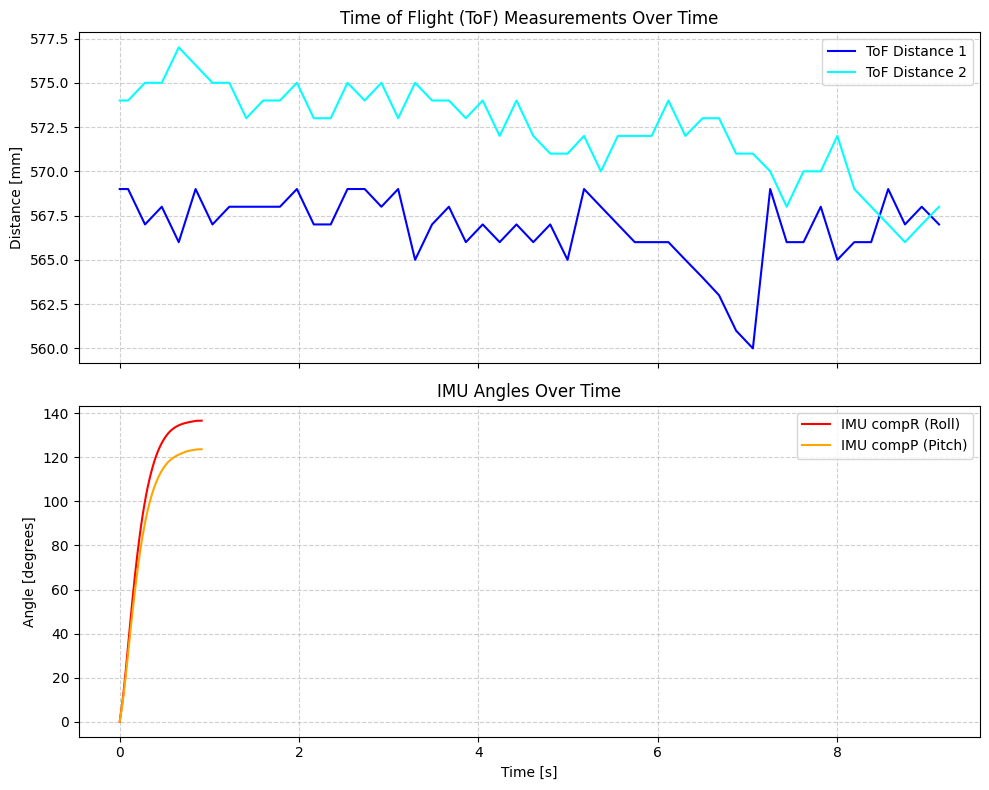

In [336]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- Top Graph: ToF Data vs Time ---
ax1.plot(times*0.001, dist1, label='ToF Distance 1', color='blue', linewidth=1.5)
ax1.plot(times*0.001, dist2, label='ToF Distance 2', color='cyan', linewidth=1.5)
ax1.set_title('Time of Flight (ToF) Measurements Over Time')
ax1.set_ylabel('Distance [mm]') # Assuming mm based on standard ToF output
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right')

# --- Bottom Graph: IMU Data vs Time ---
# Assuming compR and compP stand for Complementary Filter Roll and Pitch
ax2.plot(times*0.0001, compR, label='IMU compR (Roll)', color='red', linewidth=1.5)
ax2.plot(times*0.0001, compP, label='IMU compP (Pitch)', color='orange', linewidth=1.5)
ax2.set_title('IMU Angles Over Time')
ax2.set_xlabel('Time [s]') # Assuming your time array is in seconds
ax2.set_ylabel('Angle [degrees]') 
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right')

# Automatically adjust padding so labels don't overlap
plt.tight_layout()

# Display the graphs
plt.show()